# EDA分析

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

from pathlib import Path

# 读数据
data_path = Path("Data/H100_Real/Pune_H100_2GB_binary.csv")
df = pd.read_csv(data_path)

# print(df.head())
# print(df.info())
# print(df.describe())
def extract_mapping_features(mapping_str):
    """
    将 GPU_Mapping_Across_Nodes 的字符串解析成结构特征。
    假设是形如 [[1,0,...],[...],...] 的 4x8 矩阵。
    """
    arr = np.array(ast.literal_eval(mapping_str), dtype=int)  # shape: (4, 8)
    
    # 每个节点的 GPU 数
    node_gpu_counts = arr.sum(axis=1)  # 长度 4
    nodes_used = int((node_gpu_counts > 0).sum())
    max_per_node = int(node_gpu_counts.max())
    
    nonzero = node_gpu_counts[node_gpu_counts > 0]
    min_per_node_nonzero = int(nonzero.min()) if len(nonzero) > 0 else 0
    
    std_per_node = float(node_gpu_counts.std())
    imbalance = max_per_node - min_per_node_nonzero if len(nonzero) > 0 else 0

    return pd.Series({
        "node0_gpus": node_gpu_counts[0],
        "node1_gpus": node_gpu_counts[1],
        "node2_gpus": node_gpu_counts[2],
        "node3_gpus": node_gpu_counts[3],
        "nodes_used": nodes_used,
        "max_per_node": max_per_node,
        "min_per_node_nonzero": min_per_node_nonzero,
        "std_per_node": std_per_node,
        "imbalance": imbalance,
    })

# 应用到整个数据集
mapping_features = df["GPU_Mapping_Across_Nodes"].apply(extract_mapping_features)
df_feat = pd.concat([df, mapping_features], axis=1)

# 简单 sanity check：节点 GPU 数之和应该等于 Total_GPU_Count
check = (df_feat[["node0_gpus","node1_gpus","node2_gpus","node3_gpus"]].sum(axis=1)
         - df_feat["Total_GPU_Count"])
print("max abs diff between sum(node_gpus) and Total_GPU_Count:", check.abs().max())


max abs diff between sum(node_gpus) and Total_GPU_Count: 0.0


In [2]:
# 读取 Het-4Mix 带宽数据，并对齐为与 H100 实测数据相同的表结构
# 思路（修正版）：
# - H100 是同构集群，同一个跨节点模式（GPU_Mapping_Across_Nodes）在 4 个节点之间是完全对称的；
#   例如 "某 2 卡在某个节点" 的模式，无论是哪一台 H100 机器启用 2 卡，带宽都相同，因此 CSV 中只保留一条范式数据。
# - Het-4Mix 是异构集群（4090/A800/A6000/V100），同一个跨节点范式在不同物理节点上实现时带宽不同，
#   因此必须把 H100 中的每个范式在 4 个节点上的所有排列情况都“展开”（最多 4!=24 条），
#   生成覆盖所有物理节点分配情况的 Het-4Mix 数据。
# - 对于每个展开后的配置：
#   * 使用 core.bandwidth 中的单机带宽字典（4090/A800/A6000/V100 对应的 *_gpu_bw_dict.pkl），按节点类型和节点内 8 卡模式查单机带宽；
#   * 对所有“有 GPU”的节点取最小值作为集群内部瓶颈带宽；
#   * 再与该行 H100 跨节点实测带宽比较，取二者的最小值，作为最终 Het-4Mix 带宽。
# - 最终得到 df_het：在行数上是对 df 的拓展（每行最多 24 倍），列结构（OP / Total_GPU_Count / GPU_Mapping_Across_Nodes / data_size / Bandwidth(GB/s)）与 H100 保持一致，
#   并额外构造 df_feat，包含与原始分析相同的特征列，方便后续直接复用 EDA 与建模代码。

import itertools
from core.bandwidth import load_gpu_bw_dict, CUSTOM_CLUSTER_NODE_TYPES

# 1. 加载 Het-4Mix 对应的单机带宽字典
bandwidth_dict_dir = Path("Data/Bandwidth")
het4mix_node_types = CUSTOM_CLUSTER_NODE_TYPES["Het-4Mix"]  # ["4090", "A800", "A6000", "V100"]

# 为每种 GPU 型号加载一个带宽查找字典，键为长度为 8 的 GPU 使用模式元组，值为该模式下的带宽
het4mix_bw_dicts = {}
for gpu_type in het4mix_node_types:
    dict_path = bandwidth_dict_dir / f"{gpu_type}_gpu_bw_dict.pkl"
    het4mix_bw_dicts[gpu_type] = load_gpu_bw_dict(dict_path)


def compute_het4mix_bandwidth(mapping_str: str, h100_bw: float) -> float:
    """根据 GPU 映射与 H100 实测带宽，计算对应的 Het-4Mix 瓶颈带宽。

    参数说明：
    - mapping_str: 来自 CSV 中的 GPU_Mapping_Across_Nodes 字符串（形如 "[[1,0,...],[...],...]"），表示 4 个物理节点（4090/A800/A6000/V100）各自 8 卡的使用情况
    - h100_bw: 对应 H100 范式行的 Bandwidth(GB/s)，视为跨节点链路带宽基线

    返回：
    - 对应 Het-4Mix 集群在该映射下的最终带宽（内部节点瓶颈与跨节点带宽的最小值）
    """
    # 将形如 "[[1,0,...],[...],...]" 的字符串解析为 (4, 8) 的整型数组
    arr = np.array(ast.literal_eval(mapping_str), dtype=int)

    num_nodes = arr.shape[0]
    node_bandwidths = []  # 记录每个“有 GPU”节点的单机带宽

    for node_idx in range(num_nodes):
        node_gpu_pattern = arr[node_idx]  # 长度 8 的 0/1 向量
        # 如果该节点完全未使用 GPU，则跳过，不参与瓶颈计算
        if node_gpu_pattern.sum() == 0:
            continue

        # 选择该节点对应的 GPU 型号（按 Het-4Mix 顺序：4090/A800/A6000/V100）
        gpu_type = het4mix_node_types[node_idx % len(het4mix_node_types)]
        bw_dict = het4mix_bw_dicts[gpu_type]

        # 字典的键是长度 8 的整型元组
        key = tuple(int(x) for x in node_gpu_pattern.tolist())
        node_bw = float(bw_dict.get(key, 0.0))  # 若查不到则回退为 0.0，表示该模式未测到
        node_bandwidths.append(node_bw)

    # 若没有任何节点使用 GPU，则返回 0 带宽
    if not node_bandwidths:
        return 0.0

    # 集群内部通信瓶颈：有 GPU 的各节点单机带宽的最小值
    intra_bottleneck = float(min(node_bandwidths))

    # 最终 Het-4Mix 带宽：内部瓶颈与 H100 跨节点带宽的共同瓶颈
    final_bw = float(min(intra_bottleneck, float(h100_bw)))
    return final_bw


def expand_h100_to_het4mix(df_h100: pd.DataFrame) -> pd.DataFrame:
    """将 H100 同构范式表拓展为 Het-4Mix 异构表。

    对于每一行 H100 数据（一个 4x8 的 GPU_Mapping_Across_Nodes 范式）：
    - 生成该 4 行在物理节点 [4090, A800, A6000, V100] 上的所有排列（最多 4!=24 种）；
    - 对每个排列计算 Het-4Mix 单机瓶颈 + 跨节点瓶颈后的最终带宽；
    - 生成一条新的记录，保持 OP / Total_GPU_Count / data_size(B) 一致，仅替换映射与带宽；
    最终返回一个行数扩展后的 df_het，列结构与 df_h100 完全一致。
    """
    expanded_rows: list[dict] = []

    for _, row in df_h100.iterrows():
        base = row.to_dict()
        # H100 范式的逻辑节点映射（4x8）
        arr = np.array(ast.literal_eval(row["GPU_Mapping_Across_Nodes"]), dtype=int)
        num_nodes = arr.shape[0]

        # 所有物理节点排列：perm[i] 表示物理节点 i（4090/A800/A6000/V100）对应的 H100 逻辑行索引
        for perm in itertools.permutations(range(num_nodes)):
            permuted_arr = np.array([arr[logical_idx] for logical_idx in perm], dtype=int)
            mapping_str = str(permuted_arr.tolist())

            het_bw = compute_het4mix_bandwidth(mapping_str, base["Bandwidth(GB/s)"])

            new_row = base.copy()
            new_row["GPU_Mapping_Across_Nodes"] = mapping_str
            new_row["Bandwidth(GB/s)"] = het_bw
            expanded_rows.append(new_row)

    df_het_local = pd.DataFrame(expanded_rows, columns=df_h100.columns)
    return df_het_local


# 2. 基于 H100 实测表 df，构建拓展后的 Het-4Mix DataFrame
#    注意：这里会显著放大样本数（最多约 494 * 24 行），请在需要时再运行本单元

df_het = expand_h100_to_het4mix(df)

print("[Het-4Mix] 拓展构造完成: 原始 H100 行数 =", len(df), "; 拓展后 Het-4Mix 行数 =", len(df_het))
print(df_het.head())

# 3. 基于 Het-4Mix 数据重新生成特征，并覆盖 df_feat，方便后续代码直接复用
# het_mapping_features = df_het["GPU_Mapping_Across_Nodes"].apply(extract_mapping_features)
# df_feat = pd.concat([df_het, het_mapping_features], axis=1)

# check_het = (
#     df_feat[["node0_gpus", "node1_gpus", "node2_gpus", "node3_gpus"]].sum(axis=1)
#     - df_feat["Total_GPU_Count"]
# )
# print("[Het-4Mix] max abs diff between sum(node_gpus) and Total_GPU_Count:", check_het.abs().max())


[Het-4Mix] 拓展构造完成: 原始 H100 行数 = 494 ; 拓展后 Het-4Mix 行数 = 11856
                OP  Total_GPU_Count  \
0  all_reduce_perf                2   
1  all_reduce_perf                2   
2  all_reduce_perf                2   
3  all_reduce_perf                2   
4  all_reduce_perf                2   

                            GPU_Mapping_Across_Nodes  data_size(B)  \
0  [[1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, ...    2147483648   
1  [[1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, ...    2147483648   
2  [[1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...    2147483648   
3  [[1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...    2147483648   
4  [[1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...    2147483648   

   Bandwidth(GB/s)  
0              0.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  


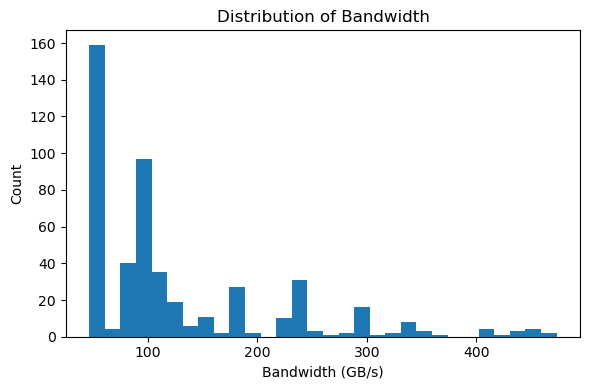

In [3]:
#带宽整体分布
plt.figure(figsize=(6,4))
plt.hist(df_feat["Bandwidth(GB/s)"], bins=30)
plt.xlabel("Bandwidth (GB/s)")
plt.ylabel("Count")
plt.title("Distribution of Bandwidth")
plt.tight_layout()
plt.show()


   Total_GPU_Count  count        mean         std
0                2      3  145.633333  171.245015
1                3      3  150.056667  178.474361
2                4      5  132.000000  133.476907
3                5      6  127.408333  143.064551
4                6      9  131.860000  130.016429
5                7     11  118.968182  129.065397
6                8     15  127.504667  128.273303
7                9     17   97.751765   83.868041
8               10     21  108.182857  103.961726
9               11     23  101.330435   97.879731


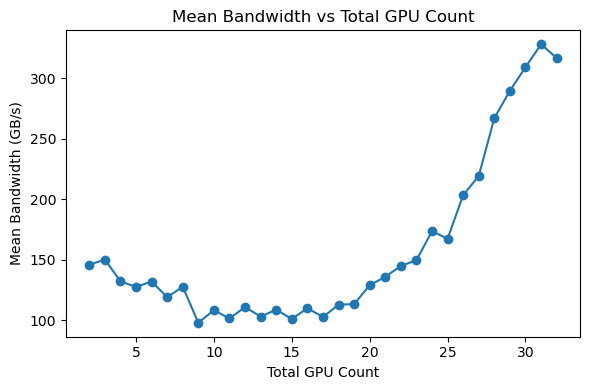

In [21]:
#不同卡数下的带宽
gpu_bw_stats = (df_feat
                .groupby("Total_GPU_Count")["Bandwidth(GB/s)"]
                .agg(["count", "mean", "std"])
                .reset_index()
                .sort_values("Total_GPU_Count"))
print(gpu_bw_stats.head(10))

# 可视化：卡数 vs 带宽均值
plt.figure(figsize=(6,4))
plt.plot(gpu_bw_stats["Total_GPU_Count"], gpu_bw_stats["mean"], marker="o")
plt.xlabel("Total GPU Count")
plt.ylabel("Mean Bandwidth (GB/s)")
plt.title("Mean Bandwidth vs Total GPU Count")
plt.tight_layout()
plt.show()


    Total_GPU_Count       mean        std
0                 2  72.816667  85.622508
1                 3  50.018889  59.491454
2                 4  33.000000  33.369227
3                 5  25.481667  28.612910
4                 6  21.976667  21.669405
5                 7  16.995455  18.437914
6                 8  15.938083  16.034163
7                 9  10.861307   9.318671
8                10  10.818286  10.396173
9                11   9.211858   8.898157
10               12   9.233086   8.908439
11               13   7.911538   7.647148
12               14   7.760714   7.201121
13               15   6.724022   5.439846
14               16   6.866364   5.236078
15               17   6.030190   3.518216
16               18   6.259552   3.626778
17               19   5.961466   3.350707
18               20   6.438907   3.592045
19               21   6.465673   3.797270


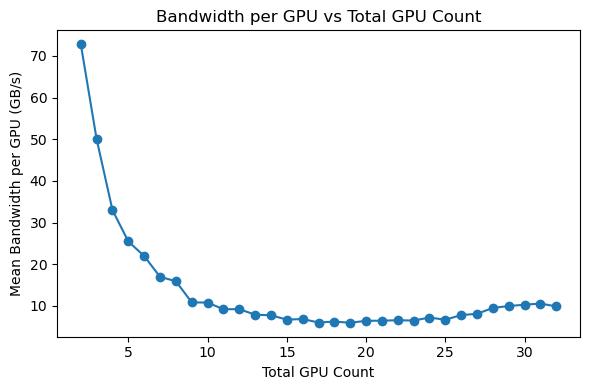

In [5]:
#每卡带宽，分析线性拓展
df_feat["bw_per_gpu"] = df_feat["Bandwidth(GB/s)"] / df_feat["Total_GPU_Count"]

gpu_bw_per_gpu = (df_feat
                  .groupby("Total_GPU_Count")["bw_per_gpu"]
                  .agg(["mean", "std"])
                  .reset_index()
                  .sort_values("Total_GPU_Count"))
print(gpu_bw_per_gpu.head(20))

plt.figure(figsize=(6,4))
plt.plot(gpu_bw_per_gpu["Total_GPU_Count"], gpu_bw_per_gpu["mean"], marker="o")
plt.xlabel("Total GPU Count")
plt.ylabel("Mean Bandwidth per GPU (GB/s)")
plt.title("Bandwidth per GPU vs Total GPU Count")
plt.tight_layout()
plt.show()


   nodes_used  count        mean         std
0         1.0      7  405.238571   52.324703
1         2.0     37  247.078919  145.944866
2         3.0    120  127.090500   83.168540
3         4.0    330  105.517455   68.709899


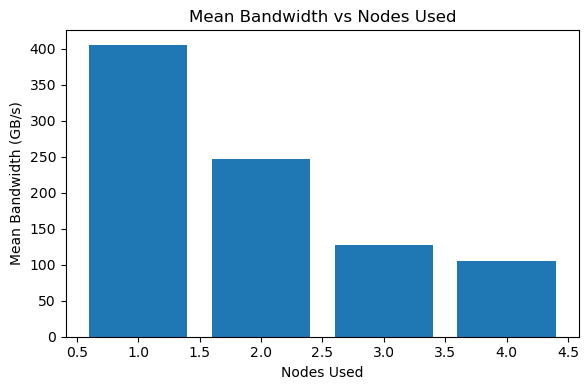

In [22]:
#使用节点数量 对带宽的影响
nodes_used_stats = (df_feat
                    .groupby("nodes_used")["Bandwidth(GB/s)"]
                    .agg(["count", "mean", "std"])
                    .reset_index()
                    .sort_values("nodes_used"))
print(nodes_used_stats)

plt.figure(figsize=(6,4))
plt.bar(nodes_used_stats["nodes_used"], nodes_used_stats["mean"])
plt.xlabel("Nodes Used")
plt.ylabel("Mean Bandwidth (GB/s)")
plt.title("Mean Bandwidth vs Nodes Used")
plt.tight_layout()
plt.show()


   imbalance  count        mean         std
0        0.0     32  272.210312  139.886841
1        1.0     42  205.569524  118.864054
2        2.0     60  172.793667  101.769264
3        3.0     75  141.896667   79.947084
4        4.0     84  112.590000   54.317340
5        5.0     84   82.655595   29.679860
6        6.0     72   70.517222   23.095769
7        7.0     45   49.284889    4.495410


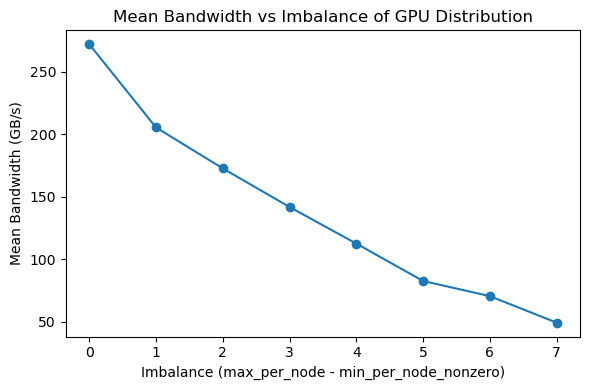

In [7]:
#节点均衡程度对带宽的影响
imbalance_stats = (df_feat
                   .groupby("imbalance")["Bandwidth(GB/s)"]
                   .agg(["count", "mean", "std"])
                   .reset_index()
                   .sort_values("imbalance"))
print(imbalance_stats.head(20))

plt.figure(figsize=(6,4))
plt.plot(imbalance_stats["imbalance"], imbalance_stats["mean"], marker="o")
plt.xlabel("Imbalance (max_per_node - min_per_node_nonzero)")
plt.ylabel("Mean Bandwidth (GB/s)")
plt.title("Mean Bandwidth vs Imbalance of GPU Distribution")
plt.tight_layout()
plt.show()


   min_per_node_nonzero  count        mean        std
0                   1.0    165   49.568182   4.851038
1                   2.0    120   94.940583  27.237197
2                   3.0     84  123.318214  46.137803
3                   4.0     56  198.307143  54.904100
4                   5.0     35  267.029714  60.920970
5                   6.0     20  320.753500  61.204454
6                   7.0     10  370.430000  58.382227
7                   8.0      4  387.312500  92.001845


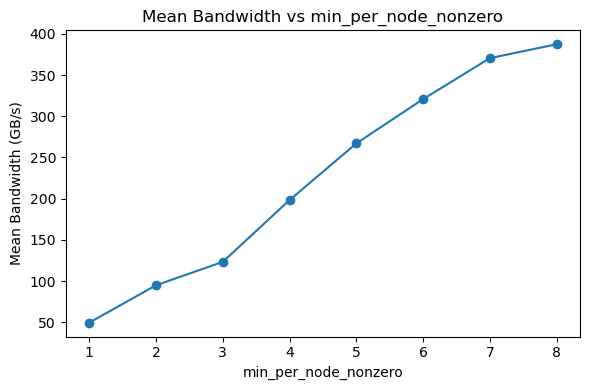

In [8]:
#min_per_node_nonzero对带宽的影响
min_per_node_stats = (df_feat
                   .groupby("min_per_node_nonzero")["Bandwidth(GB/s)"]
                   .agg(["count", "mean", "std"])
                   .reset_index()
                   .sort_values("min_per_node_nonzero"))
print(min_per_node_stats.head(20))

plt.figure(figsize=(6,4))
plt.plot(min_per_node_stats["min_per_node_nonzero"], min_per_node_stats["mean"], marker="o")
plt.xlabel("min_per_node_nonzero")
plt.ylabel("Mean Bandwidth (GB/s)")
plt.title("Mean Bandwidth vs min_per_node_nonzero")
plt.tight_layout()
plt.show()


In [23]:
#哪些特征对带宽的相关性最强
corr_cols = [
    "Total_GPU_Count",
    "nodes_used",
    "max_per_node",
    "min_per_node_nonzero",
    "std_per_node",
    "imbalance",
    # "bw_per_gpu"
]
print(df_feat[["Bandwidth(GB/s)", 'imbalance']].head())
corr = df_feat[["Bandwidth(GB/s)"] + corr_cols].corr()
print("-----"*20)
print(corr["Bandwidth(GB/s)"].sort_values(ascending=False))


   Bandwidth(GB/s)  imbalance
0            46.65        0.0
1           343.37        0.0
2            46.88        0.0
3            47.60        0.0
4            46.43        1.0
----------------------------------------------------------------------------------------------------
Bandwidth(GB/s)         1.000000
min_per_node_nonzero    0.909063
Total_GPU_Count         0.237226
max_per_node            0.155838
std_per_node           -0.002923
nodes_used             -0.466020
imbalance              -0.619772
Name: Bandwidth(GB/s), dtype: float64


# 模型预测

In [10]:
# LR线性回归
feature_cols = [
    "Total_GPU_Count",
    "nodes_used",
    "max_per_node",
    "min_per_node_nonzero",
    "std_per_node",
    "imbalance",
    "node0_gpus",
    "node1_gpus",
    "node2_gpus",
    "node3_gpus",
]

X = df_feat[feature_cols]
y = df_feat["Bandwidth(GB/s)"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lr = linreg.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
# 有的 scikit-learn 版本 mean_squared_error 没有 squared 参数，可以手动开方
try:
    rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
except TypeError:
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print("  MAE :", mae_lr)
print("  RMSE:", rmse_lr)
print("  R^2 :", r2_lr)

# 查看系数，理解影响方向
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": linreg.coef_
}).sort_values("coef", key=abs, ascending=False)
print(coef_df)


Linear Regression:
  MAE : 23.110844194047917
  RMSE: 28.906007940960276
  R^2 : 0.9120346122875687
                feature       coef
1            nodes_used -40.641831
4          std_per_node  37.685930
3  min_per_node_nonzero  24.177464
5             imbalance -22.661175
9            node3_gpus  14.260778
8            node2_gpus  -6.925927
0       Total_GPU_Count   4.447555
7            node1_gpus  -4.403586
6            node0_gpus   1.516289
2          max_per_node   1.516289


Random Forest:
  MAE : 3.874379124579167
  RMSE: 6.935515767379841
  R^2 : 0.9949360068129596


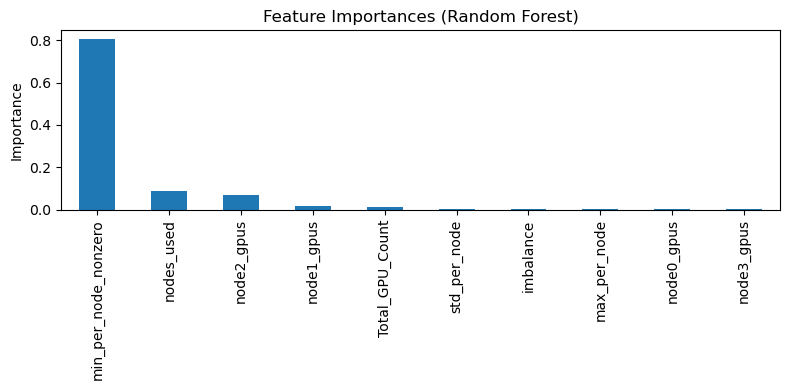

In [11]:
#使用随机森林预测
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
try:
    rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
except TypeError:
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print("  MAE :", mae_rf)
print("  RMSE:", rmse_rf)
print("  R^2 :", r2_rf)

# 特征重要性
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
# print(importances)

plt.figure(figsize=(8,4))
importances.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [12]:
# 使用OLS回归来做分析
import statsmodels.api as sm

# statsmodels 需要显式加常数项
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit()

print("OLS Regression Summary:")
print(ols_results.summary())

# 预测
y_pred_ols = ols_results.predict(X_test_sm)

# 计算各类指标
mae_ols = mean_absolute_error(y_test, y_pred_ols)
try:
    rmse_ols = mean_squared_error(y_test, y_pred_ols, squared=False)
except TypeError:
    rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols = r2_score(y_test, y_pred_ols)

print("OLS Regression Metrics:")
print("  MAE :", mae_ols)
print("  RMSE:", rmse_ols)
print("  R^2 :", r2_ols)

# 查看OLS回归的各特征系数
ols_coef_df = pd.DataFrame({
    "feature": ["const"] + feature_cols,
    "coef": ols_results.params.values
}).sort_values("coef", key=abs, ascending=False)

print(ols_coef_df)


OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:        Bandwidth(GB/s)   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     582.2
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          4.40e-201
Time:                        09:35:31   Log-Likelihood:                -1868.6
No. Observations:                 395   AIC:                             3753.
Df Residuals:                     387   BIC:                             3785.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const   

GradientBoostingRegressor:
  MAE : 3.9506322450947504
  RMSE: 7.427534234436394
  R^2 : 0.9941920226997714


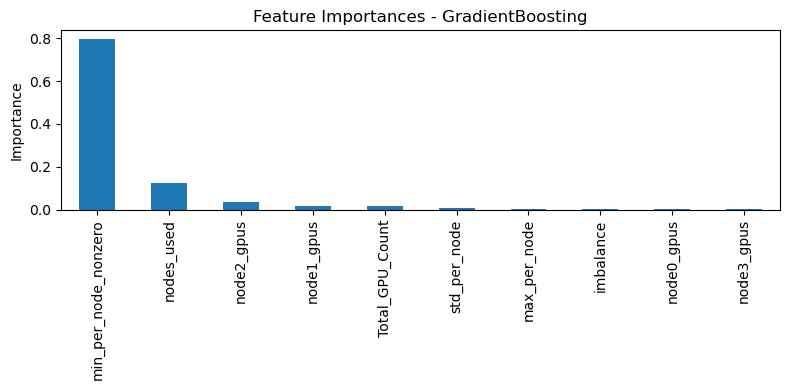

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. 定义模型（超参可以再调）
gb_model = GradientBoostingRegressor(
    n_estimators=300,      # 树的数量
    learning_rate=0.05,    # 学习率
    max_depth=20,           # 每棵树的最大深度
    subsample=0.6,         # 每棵树用的样本比例
    random_state=42
)

# 2. 训练
gb_model.fit(X_train, y_train)

# 3. 在测试集上预测
y_pred_gb = gb_model.predict(X_test)

# 4. 评估性能
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("GradientBoostingRegressor:")
print("  MAE :", mae_gb)
print("  RMSE:", rmse_gb)
print("  R^2 :", r2_gb)

# 5. 看一下特征重要性
import matplotlib.pyplot as plt

gb_importances = pd.Series(gb_model.feature_importances_, index=feature_cols)
gb_importances = gb_importances.sort_values(ascending=False)
# print("GB feature importances:")
# print(gb_importances)

plt.figure(figsize=(8,4))
gb_importances.plot(kind="bar")
plt.title("Feature Importances - GradientBoosting")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


/home/ldaphome/zkm/.conda/envs/gpu_dp_opt/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


XGBoost Regressor:
  MAE : 6.603391304401436
  RMSE: 12.295110527623413
  R^2 : 0.9840852265647698
XGBoost feature importances:
min_per_node_nonzero    0.303881
nodes_used              0.156914
node3_gpus              0.147918
imbalance               0.145585
node0_gpus              0.115776
node2_gpus              0.059461
max_per_node            0.038214
node1_gpus              0.013305
Total_GPU_Count         0.012028
std_per_node            0.006918
dtype: float32


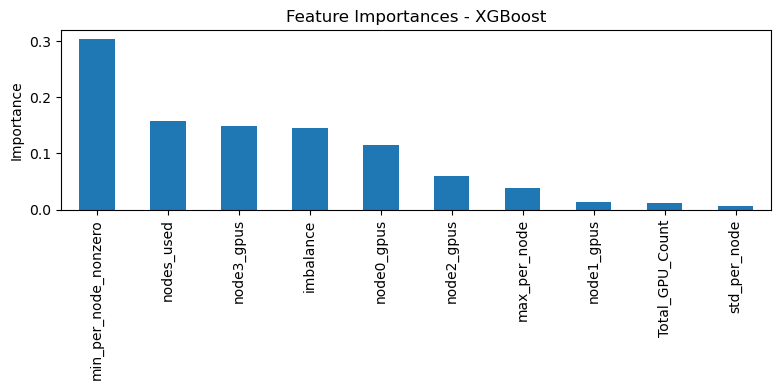

In [14]:
import xgboost as xgb

# 1. 定义 XGBoost 回归模型
xgb_model = xgb.XGBRegressor(
    n_estimators=300,           # 树的数量
    learning_rate=0.05,         # 学习率
    max_depth=20,                # 树深度
    subsample=0.6,              # 样本采样比例
    colsample_bytree=0.6,       # 特征采样比例
    objective="reg:squarederror",
    reg_lambda=1.0,             # L2 正则
    random_state=42,
    n_jobs=-1
)

# 2. 训练
xgb_model.fit(X_train, y_train)

# 3. 在测试集上预测
y_pred_xgb = xgb_model.predict(X_test)

# 4. 评估性能
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor:")
print("  MAE :", mae_xgb)
print("  RMSE:", rmse_xgb)
print("  R^2 :", r2_xgb)

# 5. 特征重要性（基于 gain）
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("XGBoost feature importances:")
print(xgb_importances)

plt.figure(figsize=(8,4))
xgb_importances.plot(kind="bar")
plt.title("Feature Importances - XGBoost")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# 进阶

In [15]:
# 分卡数分层的 Cross-Validation

# 目标：让每个 fold 里不同 Total_GPU_Count 的分布尽量一致。
# 做法：用 Total_GPU_Count 当作“分层标签”，用 StratifiedKFold 手动循环做 CV
feature_cols = [
    "Total_GPU_Count",
    "nodes_used",
    "max_per_node",
    "min_per_node_nonzero",
    "std_per_node",
    "imbalance",
    "node0_gpus",
    "node1_gpus",
    "node2_gpus",
    "node3_gpus",
]

X = df_feat[feature_cols]
y = df_feat["Bandwidth(GB/s)"]

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 分层标签：直接用卡数（如果卡数种类特别多，也可以预先做分箱）
strata = df_feat["Total_GPU_Count"].values

def cv_eval_model(model, X, y, strata, n_splits=5, model_name="model"):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    
    maes, rmses, r2s = [], [], []
    
    fold = 1
    for train_idx, val_idx in skf.split(X, strata):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 重新 fit 一次（每个 fold 独立）
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred) )
        r2 = r2_score(y_val, y_pred)
        
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        
        print(f"[{model_name}] Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R^2={r2:.4f}")
        fold += 1
    
    print(f"\n[{model_name}] CV Summary ({n_splits} folds, stratified by Total_GPU_Count):")
    print(f"  MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"  RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"  R^2 : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
    return maes, rmses, r2s

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
# import xgboost as xgb

gb_model_cv = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.6,
    random_state=42
)

# 新增：RandomForestRegressor for CV，与单模型设置一致
rf_model_cv = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

xgb_model_cv = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

print("==== RandomForestRegressor (CV) ====")
rf_maes, rf_rmses, rf_r2s = cv_eval_model(
    rf_model_cv, X, y, strata,
    n_splits=5,
    model_name="RandomForest"
)

print("\n==== GradientBoostingRegressor (CV) ====")
gb_maes, gb_rmses, gb_r2s = cv_eval_model(
    gb_model_cv, X, y, strata,
    n_splits=5,
    model_name="GradientBoosting"
)

print("\n==== XGBoostRegressor (CV) ====")
xgb_maes, xgb_rmses, xgb_r2s = cv_eval_model(
    xgb_model_cv, X, y, strata,
    n_splits=5,
    model_name="XGBoost"
)


==== RandomForestRegressor (CV) ====


/home/ldaphome/zkm/.conda/envs/gpu_dp_opt/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[RandomForest] Fold 1: MAE=3.9671, RMSE=12.5357, R^2=0.9857
[RandomForest] Fold 2: MAE=6.3660, RMSE=15.3309, R^2=0.9772
[RandomForest] Fold 3: MAE=4.3586, RMSE=9.9585, R^2=0.9879
[RandomForest] Fold 4: MAE=4.4232, RMSE=8.9083, R^2=0.9899
[RandomForest] Fold 5: MAE=4.1195, RMSE=10.8590, R^2=0.9827

[RandomForest] CV Summary (5 folds, stratified by Total_GPU_Count):
  MAE : 4.6469 ± 0.8751
  RMSE: 11.5185 ± 2.2472
  R^2 : 0.9847 ± 0.0044

==== GradientBoostingRegressor (CV) ====


/home/ldaphome/zkm/.conda/envs/gpu_dp_opt/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[GradientBoosting] Fold 1: MAE=3.2363, RMSE=7.8862, R^2=0.9943
[GradientBoosting] Fold 2: MAE=4.6544, RMSE=9.1292, R^2=0.9919
[GradientBoosting] Fold 3: MAE=4.1666, RMSE=8.7252, R^2=0.9907
[GradientBoosting] Fold 4: MAE=5.0542, RMSE=9.9112, R^2=0.9875
[GradientBoosting] Fold 5: MAE=3.5916, RMSE=9.8590, R^2=0.9857

[GradientBoosting] CV Summary (5 folds, stratified by Total_GPU_Count):
  MAE : 4.1406 ± 0.6661
  RMSE: 9.1021 ± 0.7548
  R^2 : 0.9901 ± 0.0031

==== XGBoostRegressor (CV) ====


/home/ldaphome/zkm/.conda/envs/gpu_dp_opt/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[XGBoost] Fold 1: MAE=5.1179, RMSE=9.7233, R^2=0.9914
[XGBoost] Fold 2: MAE=6.8415, RMSE=13.9863, R^2=0.9810
[XGBoost] Fold 3: MAE=5.3244, RMSE=8.7212, R^2=0.9907
[XGBoost] Fold 4: MAE=4.9161, RMSE=9.7542, R^2=0.9879
[XGBoost] Fold 5: MAE=6.2739, RMSE=11.5676, R^2=0.9804

[XGBoost] CV Summary (5 folds, stratified by Total_GPU_Count):
  MAE : 5.6948 ± 0.7385
  RMSE: 10.7505 ± 1.8603
  R^2 : 0.9863 ± 0.0047


Prediction interval coverage (should be ~0.8): 0.838


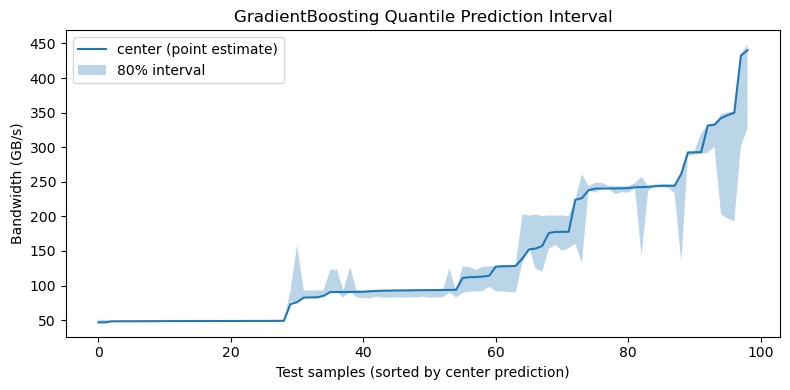

Center prediction     : 337.2157118494383
80% interval [lower, upper]: (205.3065922084986, 342.2084715707062)


In [16]:
# 不确定性分析（预测区间）
from sklearn.ensemble import GradientBoostingRegressor

# 训练下界模型（10% 分位数）
gb_lower = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.1,
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb_lower.fit(X, y)

# 训练上界模型（90% 分位数）
gb_upper = GradientBoostingRegressor(
    loss="quantile",
    alpha=0.9,
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb_upper.fit(X, y)

# 中心估计可以用你之前的 gb_model（平方误差 loss）
gb_center = GradientBoostingRegressor(
    loss="squared_error",
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.6,
    random_state=42
)
gb_center.fit(X, y)

import matplotlib.pyplot as plt

y_pred_center = gb_center.predict(X_test)
y_pred_lower  = gb_lower.predict(X_test)
y_pred_upper  = gb_upper.predict(X_test)

# 看一下区间覆盖率：真实 y 落在区间里的比例
coverage = np.mean((y_test >= y_pred_lower) & (y_test <= y_pred_upper))
print(f"Prediction interval coverage (should be ~0.8): {coverage:.3f}")

# 简单画一下：按预测值排序后画带
order = np.argsort(y_pred_center)
plt.figure(figsize=(8,4))
plt.plot(y_pred_center[order], label="center (point estimate)")
plt.fill_between(
    np.arange(len(order)),
    y_pred_lower[order],
    y_pred_upper[order],
    alpha=0.3,
    label="80% interval"
)
plt.ylabel("Bandwidth (GB/s)")
plt.xlabel("Test samples (sorted by center prediction)")
plt.title("GradientBoosting Quantile Prediction Interval")
plt.legend()
plt.tight_layout()
plt.show()

def mapping_to_features(mapping_str):
    """
    参考 extract_mapping_features，并加入 Total_GPU_Count 特征，生成 DataFrame/Series
    """
    arr = np.array(ast.literal_eval(mapping_str), dtype=int)  # shape: (4, 8)
    
    # 每个节点的 GPU 数
    node_gpu_counts = arr.sum(axis=1)  # 长度 4
    nodes_used = int((node_gpu_counts > 0).sum())
    max_per_node = int(node_gpu_counts.max())
    nonzero = node_gpu_counts[node_gpu_counts > 0]
    min_per_node_nonzero = int(nonzero.min()) if len(nonzero) > 0 else 0
    std_per_node = float(node_gpu_counts.std())
    imbalance = max_per_node - min_per_node_nonzero if len(nonzero) > 0 else 0

    node_feats = {
        "node0_gpus": node_gpu_counts[0],
        "node1_gpus": node_gpu_counts[1],
        "node2_gpus": node_gpu_counts[2],
        "node3_gpus": node_gpu_counts[3],
    }
    total_gpu_count = int(node_gpu_counts.sum())
    
    d = {
        "Total_GPU_Count": total_gpu_count,
        "nodes_used": nodes_used,
        "max_per_node": max_per_node,
        "min_per_node_nonzero": min_per_node_nonzero,
        "std_per_node": std_per_node,
        "imbalance": imbalance,
    }
    d.update(node_feats)
    # 按 X.columns 排序
    return pd.Series(d)

def predict_with_interval(mapping_str):
    # 先提取特征为Series
    X_new_series = mapping_to_features(mapping_str)
    # 保证 DataFrame 的列顺序与训练所用 X 一致
    X_new = pd.DataFrame([X_new_series], columns=X.columns)
    # 检查是否有 NaN 并提醒用户
    if X_new.isnull().any().any():
        missing_cols = X_new.columns[X_new.isnull().any()].tolist()
        raise ValueError(f"提取的特征包含缺失值，请检查 mapping_str 和特征提取函数。缺失列: {missing_cols}\n特征内容:\n{X_new}\n")
    y_c = gb_center.predict(X_new)[0]
    y_l = gb_lower.predict(X_new)[0]
    y_u = gb_upper.predict(X_new)[0]
    
    print("Center prediction     :", y_c)
    print("80% interval [lower, upper]:", (y_l, y_u))
    return y_c, y_l, y_u

# 示例
new_mapping = str([
    [1,1,1,1,0,0,0,0],
    [1,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0],
])

try:
    _ = predict_with_interval(new_mapping)
except ValueError as e:
    print("特征生成有误！")
    print(e)



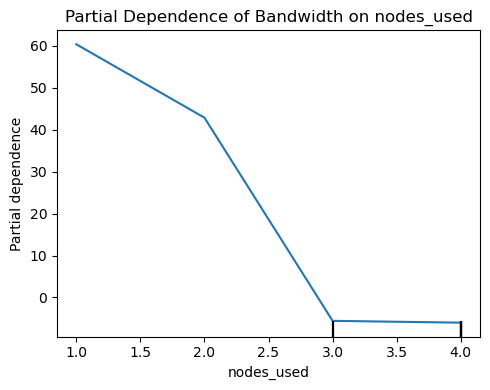

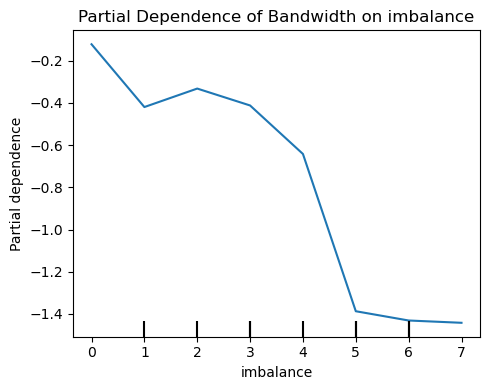

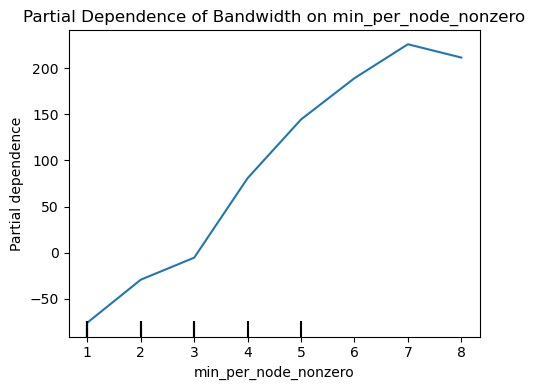

In [17]:
#边际收益
from sklearn.inspection import PartialDependenceDisplay

# 如果你还没有“全量 fit 一次”的最终模型，重新在全部数据上 fit 一次
final_gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    random_state=42
)
final_gb.fit(X, y)

# final_gb = gb_model
# 对单个特征：nodes_used
fig, ax = plt.subplots(figsize=(5,4))
PartialDependenceDisplay.from_estimator(
    final_gb,
    X,
    features=[feature_cols.index("nodes_used")],
    feature_names=feature_cols,
    ax=ax
)
plt.title("Partial Dependence of Bandwidth on nodes_used")
plt.tight_layout()
plt.show()

# 对单个特征：imbalance
fig, ax = plt.subplots(figsize=(5,4))
PartialDependenceDisplay.from_estimator(
    final_gb,
    X,
    features=[feature_cols.index("imbalance")],
    feature_names=feature_cols,
    ax=ax
)
plt.title("Partial Dependence of Bandwidth on imbalance")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,4))
PartialDependenceDisplay.from_estimator(
    final_gb,
    X,
    features=[feature_cols.index("min_per_node_nonzero")],
    feature_names=feature_cols,
    ax=ax
)
plt.title("Partial Dependence of Bandwidth on min_per_node_nonzero")
plt.tight_layout()
plt.show()


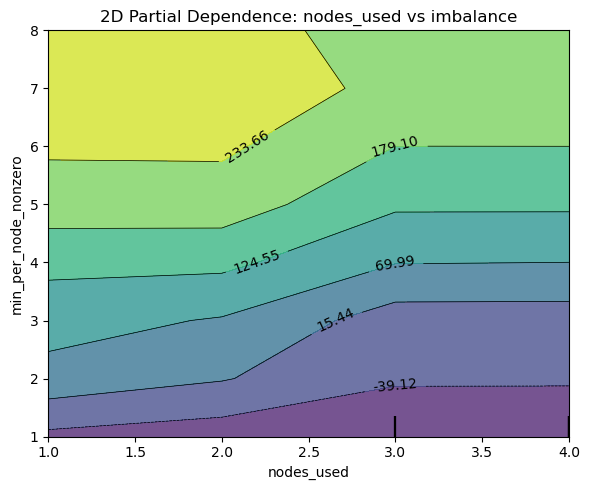

In [18]:
#观察边际效应
# 二元 PDP：nodes_used × imbalance
fig, ax = plt.subplots(figsize=(6,5))
PartialDependenceDisplay.from_estimator(
    final_gb,
    X,
    features=[(feature_cols.index("nodes_used"),
               feature_cols.index("min_per_node_nonzero"))],# imbalance
    feature_names=feature_cols,
    ax=ax
)
plt.title("2D Partial Dependence: nodes_used vs imbalance")
plt.tight_layout()
plt.show()


# 其他方案对比

In [19]:
#Classification：高/中/低带宽分类
import numpy as np
import pandas as pd

# 用 1/3, 2/3 分位数划分
q1, q2 = y.quantile([0.33, 0.66])
print("q1, q2:", q1, q2)

def label_bandwidth(bw):
    if bw < q1:
        return 0  # low
    elif bw < q2:
        return 1  # medium
    else:
        return 2  # high

y_cls = y.apply(label_bandwidth)

y_cls.value_counts()

from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

gb_clf = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_clf.fit(X_train_c, y_train_c)

y_pred_c = gb_clf.predict(X_test_c)

print("Classification Report:\n")
print(classification_report(y_test_c, y_pred_c, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))

importances = pd.Series(gb_clf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
print(importances)


q1, q2: 75.41619999999999 114.3728
Classification Report:

              precision    recall  f1-score   support

           0      0.971     1.000     0.985        33
           1      0.882     0.938     0.909        32
           2      0.968     0.882     0.923        34

    accuracy                          0.939        99
   macro avg      0.940     0.940     0.939        99
weighted avg      0.941     0.939     0.939        99

Confusion Matrix:
[[33  0  0]
 [ 1 30  1]
 [ 0  4 30]]
min_per_node_nonzero    0.821929
node2_gpus              0.040978
node3_gpus              0.034601
imbalance               0.022757
std_per_node            0.022260
nodes_used              0.019719
node1_gpus              0.018746
node0_gpus              0.008249
Total_GPU_Count         0.006347
max_per_node            0.004416
dtype: float64


In [24]:
#Clustering / Pattern Mining：拓扑模式聚类
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)
cluster_labels = kmeans.fit_predict(X_scaled)

df_feat["cluster"] = cluster_labels
df_feat["cluster"].value_counts()
cluster_summary = (df_feat
                   .groupby("cluster")
                   .agg(
                       count=("Bandwidth(GB/s)", "count"),
                       mean_bw=("Bandwidth(GB/s)", "mean"),
                       std_bw=("Bandwidth(GB/s)", "std"),
                       **{f"mean_{col}": (col, "mean") for col in feature_cols}
                   )
                   .sort_values("mean_bw", ascending=False)
                  )

pd.set_option("display.max_columns", None)
cluster_summary


,count,mean_bw,std_bw,mean_Total_GPU_Count,mean_nodes_used,mean_max_per_node,mean_min_per_node_nonzero,mean_std_per_node,mean_imbalance,mean_node0_gpus,mean_node1_gpus,mean_node2_gpus,mean_node3_gpus
cluster,,,,,,,,,,,,,
2,101,203.113564,125.032655,14.138614,2.712871,6.940594,3.693069,2.790775,3.247525,6.940594,4.643564,2.554455,0.000000
3,87,196.018966,68.603017,23.919540,4.000000,7.321839,4.413793,1.192866,2.908046,7.321839,6.528736,5.655172,4.413793
4,62,106.416935,91.557417,7.016129,2.935484,3.322581,1.774194,1.201280,1.548387,3.322581,2.080645,1.225806,0.387097
0,98,80.661633,31.504201,13.969388,3.948980,5.316327,1.887755,1.442136,3.428571,5.316327,4.010204,2.846939,1.795918
1,146,68.352055,22.463544,17.863014,3.904110,7.554795,1.547945,2.503432,6.006849,7.554795,5.602740,3.280822,1.424658


In [27]:
# Residual-based Anomaly Detection（基于残差的异常配置）
reg_model = gb_model   # 或者 reg_model = xgb_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("Regression performance on test:")
print("  MAE :", mae)
print("  RMSE:", rmse)
print("  R^2 :", r2)
# 计算残差
residuals = y_test_r - y_pred_r
abs_residuals = np.abs(residuals)

# 95% 分位数作为阈值
threshold = np.quantile(abs_residuals, 0.95)
print("residual threshold:", threshold)

# 标记异常点
anomaly_mask = abs_residuals > threshold
anomaly_indices = y_test_r.index[anomaly_mask]

print("Number of anomalies:", anomaly_mask.sum())

anomaly_df = df_feat.loc[anomaly_indices, 
                         feature_cols + ["Bandwidth(GB/s)"]].copy()
anomaly_df["y_pred"] = y_pred_r[anomaly_mask]
anomaly_df["residual"] = residuals[anomaly_mask]

# 按残差从大到小排序
anomaly_df = anomaly_df.sort_values("residual", key=np.abs, ascending=False)

pd.set_option("display.max_rows", 20)
anomaly_df.head(20)



Regression performance on test:
  MAE : 3.9506322450947504
  RMSE: 7.427534234436394
  R^2 : 0.9941920226997714
residual threshold: 18.59132740488551
Number of anomalies: 5


,Total_GPU_Count,nodes_used,max_per_node,min_per_node_nonzero,std_per_node,imbalance,node0_gpus,node1_gpus,node2_gpus,node3_gpus,Bandwidth(GB/s),y_pred,residual
104,11,2.0,7.0,4.0,2.947457,3.0,7.0,4.0,0.0,0.0,349.81,321.393143,28.416857
153,13,3.0,5.0,4.0,1.920286,1.0,5.0,4.0,4.0,0.0,224.10,199.687615,24.412385
0,2,2.0,1.0,1.0,0.500000,0.0,1.0,1.0,0.0,0.0,46.65,70.161017,-23.511017
2,2,2.0,1.0,1.0,0.500000,0.0,1.0,1.0,0.0,0.0,46.88,70.161017,-23.281017
347,19,4.0,7.0,3.0,1.479020,4.0,7.0,5.0,4.0,3.0,90.59,110.313894,-19.723894
